In [1]:
import numpy as np
import tensorflow as tf
import sys
import os

sys.path.insert(1, './seld-net')
import cls_data_generator
import parameter
import evaluation_metrics

import matplotlib.pyplot as plt
%matplotlib inline


2025-07-30 11:45:30.897648: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753850730.985210  409500 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753850730.989886  409500 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753850731.137987  409500 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753850731.138009  409500 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753850731.138012  409500 computation_placer.cc:177] computation placer alr

In [2]:
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
print(tf.config.experimental.list_physical_devices('GPU'))


Num GPUs Available:  1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
model = tf.keras.models.load_model('./models_fav/cryset/cryset_motor_ov1_split1_regr0_3d0_100_50LossWeights_model.keras')

# model.summary()

I0000 00:00:1753850736.074980  409500 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2217 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [4]:
params = parameter.get_params("31")
batch_size = 16

data_gen_test = cls_data_generator.DataGenerator(
        dataset=params['dataset'], ov=params['overlap'], split=params['split'], db=params['db'], nfft=params['nfft'],
        batch_size=batch_size, seq_len=params['sequence_length'], classifier_mode=params['mode'],
        weakness=params['weakness'], datagen_mode='test', cnn3d=params['cnn_3d'], xyz_def_zero=params['xyz_def_zero'],
        azi_only=params['azi_only'], shuffle=False
    )

azimuth_only = params['azi_only']
temp_sed_batch = next(data_gen_test.generate())[1][0]
num_of_class = int(temp_sed_batch.shape[2])

SET: 31
quick_test: False
azi_only: False
dataset: cryset_motor
overlap: 1
split: 1
db: 30
nfft: 512
sequence_length: 512
batch_size: 2
dropout_rate: 0.0
nb_cnn2d_filt: 64
pool_size: [8, 8, 2]
rnn_size: [128, 128]
fnn_size: [128]
loss_weights: [1.0, 50.0]
xyz_def_zero: True
nb_epochs: 1000
mode: regr
nb_cnn3d_filt: 32
cnn_3d: False
weakness: 0
patience: 100


Datagen_mode: test, nb_files: 60, nb_classes:1
nb_frames_file: 5166, feat_len: 256, nb_ch: 16, label_len:3

Dataset: cryset_motor, ov: 1, split: 1
batch_size: 16, seq_len: 512, shuffle: False
label_dir: ./dataset_generator/sounds/cryset_motor/label_ov1_split1_nfft512_regr0
 feat_dir: ./dataset_generator/sounds/cryset_motor/spec_ov1_split1_30db_nfft512_norm



In [5]:
print(data_gen_test.get_data_sizes())
print("feature shape: ", next(data_gen_test.generate())[0].shape)
print("SED shape: ", next(data_gen_test.generate())[1][0].shape)
print("DOA shape: ", next(data_gen_test.generate())[1][1].shape)

((16, 16, 512, 256), [(16, 512, 1), (16, 512, 3)])
feature shape:  (16, 16, 512, 256)
SED shape:  (16, 512, 1)
DOA shape:  (16, 512, 3)


In [6]:
pred = model.predict_on_batch(
    next(data_gen_test.generate())[0][:, :, :, :],
)
print("SED shape: ", pred[0].shape)
print("DOA shape: ", pred[1].shape)

I0000 00:00:1753850749.308717  409588 cuda_dnn.cc:529] Loaded cuDNN version 90501
2025-07-30 11:45:50.493707: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 670.91MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


SED shape:  (16, 512, 1)
DOA shape:  (16, 512, 3)


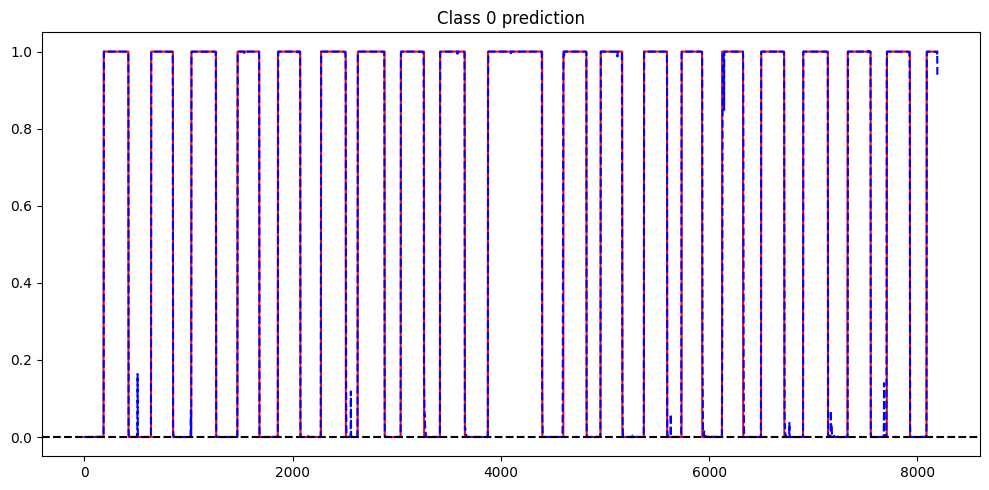

In [7]:
labels = next(data_gen_test.generate())[1][0][:, :, :].squeeze()
labels = np.concatenate([labels[n, :] for n in range(labels.shape[0])])
if len(labels.shape) == 1:
    labels = np.atleast_2d(labels).T
    
predictions = np.concatenate(([pred[0][n, :, :] for n in range(pred[0].shape[0])]))

%matplotlib inline

fig, ax = plt.subplots(num_of_class, figsize=(10, 5))
ax = np.atleast_1d(ax)
for i in range(num_of_class):
    ax[i].set_title("Class %d prediction" %i)
    ax[i].plot(labels[:, i], label='Difference', color='red')
    ax[i].plot(predictions[:, i], label='Difference', color='blue', linestyle='--')
    ax[i].axhline(y=0, color='black', linestyle='--')

# fig.legend()
plt.tight_layout()
plt.show()

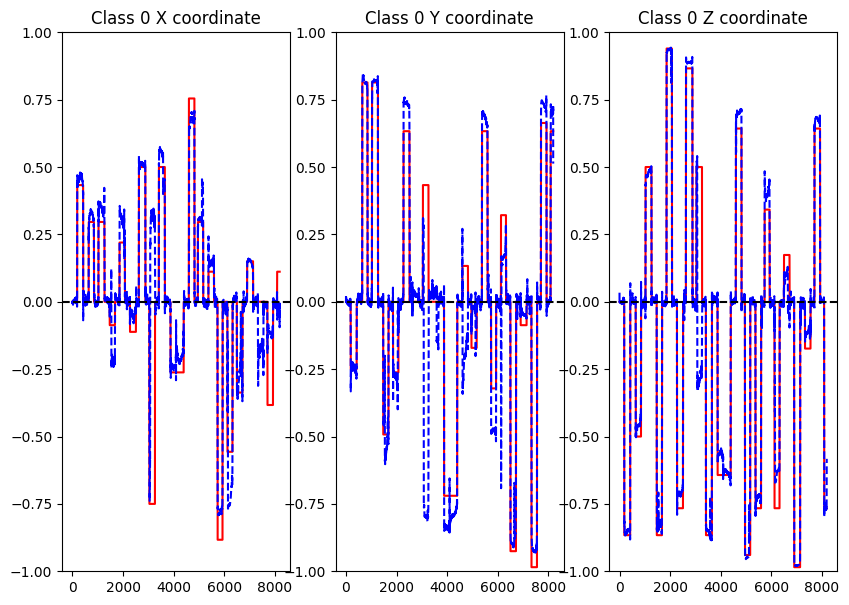

In [8]:
doa_labels = next(data_gen_test.generate())[1][1][:, :, :]

x_labels = np.concatenate([doa_labels[n, :, :] for n in range(doa_labels.shape[0])])
y_labels = np.concatenate([doa_labels[n, :, :] for n in range(doa_labels.shape[0])])
z_labels = np.concatenate([doa_labels[n, :, :] for n in range(doa_labels.shape[0])])

x_pred = np.concatenate(([pred[1][n, :, :] for n in range(pred[0].shape[0])]))
y_pred = np.concatenate(([pred[1][n, :, :] for n in range(pred[0].shape[0])]))
z_pred = np.concatenate(([pred[1][n, :, :] for n in range(pred[0].shape[0])]))

%matplotlib inline
fig, ax = plt.subplots(num_of_class, 2 if azimuth_only else 3, figsize=(10, 7))
ax = np.atleast_2d(ax)

for i in range(num_of_class):
    ax[i][0].set_title("Class %d X coordinate" %i)
    ax[i][0].plot(x_labels[:, i], label='Actual', color='red')
    ax[i][0].plot(x_pred[:, i], label='Predicted', color='blue', linestyle='--')
    ax[i][0].axhline(y=0, color='black', linestyle='--')
    ax[i][0].set_ylim([-1, 1])

    ax[i][1].set_title("Class %d Y coordinate" %i)
    ax[i][1].plot(x_labels[:, i + num_of_class], label='Actual', color='red')
    ax[i][1].plot(x_pred[:, i + num_of_class], label='Predicted', color='blue', linestyle='--')
    ax[i][1].axhline(y=0, color='black', linestyle='--')
    ax[i][1].set_ylim([-1, 1])

    ax[i][2].set_title("Class %d Z coordinate" %i)
    ax[i][2].plot(x_labels[:, i + num_of_class + num_of_class], label='Actual', color='red')
    ax[i][2].plot(x_pred[:, i + num_of_class + num_of_class], label='Predicted', color='blue', linestyle='--')
    ax[i][2].axhline(y=0, color='black', linestyle='--')
    ax[i][2].set_ylim([-1, 1])

# fig.legend()
# plt.tight_layout()
plt.show()

In [9]:
def collect_test_labels(_data_gen_test, _data_out, classification_mode, quick_test):
    # Collecting ground truth for test data
    nb_batch = 1
    batch_size = _data_out[0][0]
    gt_sed = np.zeros((nb_batch * batch_size, _data_out[0][1], _data_out[0][2]))
    gt_doa = np.zeros((nb_batch * batch_size, _data_out[0][1], _data_out[1][2]))

    cnt = 0
    for tmp_feat, tmp_label in _data_gen_test.generate():
        gt_sed[cnt * batch_size:(cnt + 1) * batch_size, :, :] = tmp_label[0]
        gt_doa[cnt * batch_size:(cnt + 1) * batch_size, :, :] = tmp_label[1]
        cnt = cnt + 1
        if cnt == nb_batch:
            break
    return gt_sed.astype(int), gt_doa

In [10]:
sed_pred = evaluation_metrics.reshape_3Dto2D(pred[0]) > 0.5
doa_pred = evaluation_metrics.reshape_3Dto2D(pred[1])

print(sed_pred.shape, doa_pred.shape)

(8192, 1) (8192, 3)


In [11]:
data_in, data_out = data_gen_test.get_data_sizes()
print(data_in, data_out[0], data_out[1])
gt = collect_test_labels(data_gen_test, data_out, params['mode'], params['quick_test'])
sed_gt = evaluation_metrics.reshape_3Dto2D(gt[0])
doa_gt = evaluation_metrics.reshape_3Dto2D(gt[1])

print(sed_gt.shape, doa_gt.shape)

(16, 16, 512, 256) (16, 512, 1) (16, 512, 3)
(8192, 1) (8192, 3)


In [12]:
sed_loss = evaluation_metrics.compute_sed_scores(sed_pred, sed_gt, data_gen_test.nb_frames_1s())
doa_loss, conf_mat = evaluation_metrics.compute_doa_scores_regr_xyz(doa_pred, doa_gt, sed_pred, sed_gt)

print("SED F1_overall:", sed_loss[1])
print("SED ER_overall:", sed_loss[0])

print("DOA doa_error_gt:", doa_loss[1])
print("DOA doa_error_pred:", doa_loss[2])

SED F1_overall: 1.0
SED ER_overall: 0.0
DOA doa_error_gt: 0.21125382173757498
DOA doa_error_pred: 0.20953707987976292
